# Task 4.1 — ABC-MCMC & Summary Statistic Experiments

For a fair comparison, we keep the same modelling as in the rejection-ABC and only change the inference algorithm. Subsequently, all differences will come from the algorithm rather than from different data, summaries, or priors.

Workflow:
1. **Generate** prior samples + raw simulations once, save to disk
2. **Load** observed data & saved simulations
3. **Define** modular scalar summary statistics — swap `ACTIVE_SET` to experiment
4. **Diagnose** summary quality via PCA scatter plots (Section 4)
-- from here, we start to differ from rejection ABC.

5. **Run** ABC-MCMC and inspect the approximate posterior (Section 5)
6. **Compare** summary sets and tolerance levels (Section 6)
7. **Improve** via semi-automatic ABC — project summaries to 3D via ridge regression (Section 7, Fearnhead & Prangle, 2012)
8. **Select** features automatically via LASSO regularisation (Section 8, Blum et al., 2013)

In [1]:
import subprocess
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT / "scripts"))

import importlib.util

spec = importlib.util.spec_from_file_location("simulator", ROOT / "scripts" / "simulator.py")
mod  = importlib.util.module_from_spec(spec)
spec.loader.exec_module(mod)

simulate_fast = mod.simulate_fast
simulate_batch = mod.simulate_batch

## 1. Generate Prior Simulations

Runs `simulate_prior.py` once and saves `data/prior_simulations.npz`.  
Re-run is skipped automatically if the file already exists — delete it to regenerate.

In [2]:
# ── Config ────────────────────────────────────────────────────────────────────
M    = 10_000   # number of prior draws
R    = 40       # replicates per draw (match observed)
SEED = 0
OUT  = ROOT / "data" / "prior_simulations.npz"

# ── Run ───────────────────────────────────────────────────────────────────────
if OUT.exists():
    print(f"Found {OUT} — skipping simulation.")
    print("Delete the file and re-run this cell to regenerate.")
else:
    result = subprocess.run(
        [
            sys.executable,
            str(ROOT / "scripts" / "simulate_prior.py"),
            "--M",    str(M),
            "--R",    str(R),
            "--seed", str(SEED),
            "--out",  str(OUT),
        ],
        capture_output=True,
        text=True,
    )
    print(result.stdout)
    if result.returncode != 0:
        print("STDERR:", result.stderr)

Found C:\Users\miche\Desktop\NUS\SimulationProject\data\prior_simulations.npz — skipping simulation.
Delete the file and re-run this cell to regenerate.


## 2. Load Data

Observed: inf=(40, 201), rew=(40, 201), deg=(40, 31)


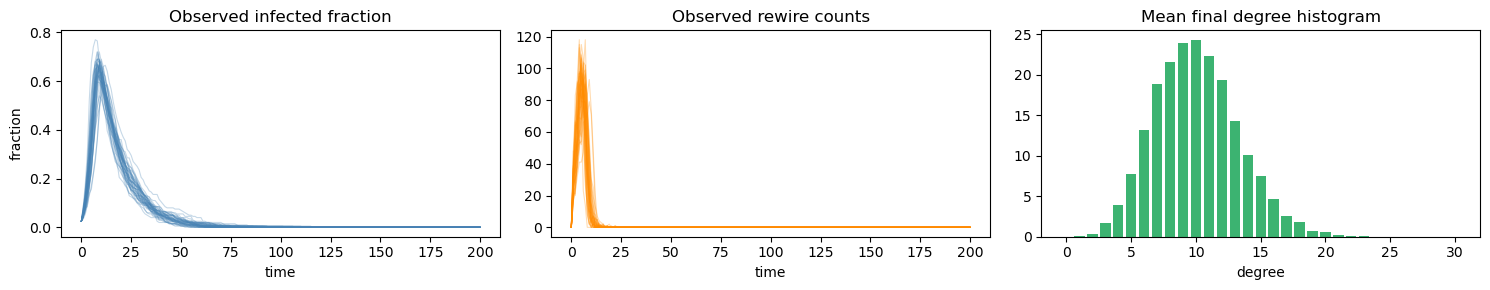

In [3]:
def load_observed(data_dir: Path):
    """Return obs_inf (R,T+1), obs_rew (R,T+1), obs_deg (R,31) as float arrays."""
    inf_df = pd.read_csv(data_dir / "infected_timeseries.csv")
    rew_df = pd.read_csv(data_dir / "rewiring_timeseries.csv")
    deg_df = pd.read_csv(data_dir / "final_degree_histograms.csv")

    obs_inf = (
        inf_df.pivot(index="replicate_id", columns="time", values="infected_fraction")
        .sort_index().values.astype(float)
    )
    obs_rew = (
        rew_df.pivot(index="replicate_id", columns="time", values="rewire_count")
        .sort_index().values.astype(float)
    )
    obs_deg = (
        deg_df.pivot(index="replicate_id", columns="degree", values="count")
        .sort_index().values.astype(float)
    )
    return obs_inf, obs_rew, obs_deg


obs_inf, obs_rew, obs_deg = load_observed(ROOT / "data")
print(f"Observed: inf={obs_inf.shape}, rew={obs_rew.shape}, deg={obs_deg.shape}")

fig, axes = plt.subplots(1, 3, figsize=(15, 3))
axes[0].plot(obs_inf.T, alpha=0.3, color="steelblue", lw=0.8)
axes[0].set(title="Observed infected fraction", xlabel="time", ylabel="fraction")
axes[1].plot(obs_rew.T, alpha=0.3, color="darkorange", lw=0.8)
axes[1].set(title="Observed rewire counts", xlabel="time")
axes[2].bar(np.arange(31), obs_deg.mean(axis=0), color="mediumseagreen")
axes[2].set(title="Mean final degree histogram", xlabel="degree")
plt.tight_layout()

In [4]:
raw = np.load(OUT)
thetas    = raw["thetas"]                            # (M, 3)  [beta, gamma, rho]
sim_inf   = raw["infected_fractions"]                # (M, R, 201)
sim_rew   = raw["rewire_counts"].astype(float)       # (M, R, 201)
sim_deg   = raw["degree_histograms"].astype(float)   # (M, R, 31)
M_loaded, R_loaded = sim_inf.shape[:2]
print(f"Loaded {M_loaded:,} draws × {R_loaded} replicates")
print(f"  thetas {thetas.shape} | inf {sim_inf.shape} | rew {sim_rew.shape} | deg {sim_deg.shape}")

Loaded 10,000 draws × 40 replicates
  thetas (10000, 3) | inf (10000, 40, 201) | rew (10000, 40, 201) | deg (10000, 40, 31)


## 3. Summary Statistics

Each feature function takes `(inf, rew, deg)` arrays of shape `(M, R, …)` and returns `(M, 1)` — a single scalar per prior draw. All summaries are scalars; time-series features are intentionally excluded because multi-dimensional features (e.g. a 20-point subsampled curve) would dominate the Euclidean distance over all scalar features combined, regardless of per-feature standardisation.

For observed data (shape `(R, …)`) we temporarily add a batch dimension.

**To experiment with different summary sets, change `ACTIVE_SET` below.**

In [5]:
# ── Degree distribution helpers ───────────────────────────────────────────────
DEGREES = np.arange(31, dtype=float)

def _degree_mean(deg):   # (M, R, 31) → (M, 1)
    total = deg.sum(axis=2, keepdims=True).clip(min=1)
    return ((deg * DEGREES).sum(axis=2, keepdims=True) / total).mean(axis=1)

def _degree_std(deg):    # (M, R, 31) → (M, 1)
    total = deg.sum(axis=2, keepdims=True).clip(min=1)
    mu  = (deg * DEGREES).sum(axis=2) / total.squeeze(2)
    mu2 = (deg * DEGREES**2).sum(axis=2) / total.squeeze(2)
    return np.sqrt((mu2 - mu**2).clip(min=0)).mean(axis=1, keepdims=True)

def _degree_entropy(deg):  # (M, R, 31) → (M, 1)
    """Shannon entropy of the degree distribution — sensitive to distribution shape."""
    total = deg.sum(axis=2, keepdims=True).clip(min=1)
    p = deg / total
    return -(p * np.log(p + 1e-10)).sum(axis=2).mean(axis=1, keepdims=True)

def _degree_quantile(deg, q):  # (M, R, 31) → (M, 1)
    """q-th quantile of the degree distribution, averaged over replicates."""
    total = deg.sum(axis=2, keepdims=True).clip(min=1)
    cdf = np.cumsum(deg / total, axis=2)          # (M, R, 31)
    return (cdf < q).sum(axis=2).astype(float).mean(axis=1, keepdims=True)

# ── Feature catalogue (scalar summaries only) ─────────────────────────────────
# All features reduce (M, R, …) → (M, 1), keeping dimensionality equal across
# modalities so no single group dominates the Euclidean distance.

FEATURE_FUNCS = {
    # --- infection ---
    "peak_inf":          lambda i, w, d: np.max(i, axis=2).mean(axis=1, keepdims=True),
    "time_to_peak_inf":  lambda i, w, d: np.argmax(i, axis=2).astype(float).mean(axis=1, keepdims=True),
    "final_inf":         lambda i, w, d: i[:, :, -1].mean(axis=1, keepdims=True),
    "total_inf":         lambda i, w, d: i.sum(axis=2).mean(axis=1, keepdims=True),
    "epidemic_duration": lambda i, w, d: (i > 0.01).sum(axis=2).astype(float).mean(axis=1, keepdims=True),
    "std_peak_inf":      lambda i, w, d: np.max(i, axis=2).std(axis=1, keepdims=True),
    "std_total_inf":     lambda i, w, d: i.sum(axis=2).std(axis=1, keepdims=True),
    # --- rewiring ---
    "total_rew":         lambda i, w, d: w.sum(axis=2).mean(axis=1, keepdims=True),
    "peak_rew":          lambda i, w, d: np.max(w, axis=2).mean(axis=1, keepdims=True),
    "time_to_peak_rew":  lambda i, w, d: np.argmax(w, axis=2).astype(float).mean(axis=1, keepdims=True),
    "std_total_rew":     lambda i, w, d: w.sum(axis=2).std(axis=1, keepdims=True),
    "std_peak_rew":      lambda i, w, d: np.max(w, axis=2).std(axis=1, keepdims=True),
    # --- degree histogram ---
    "mean_degree":       lambda i, w, d: _degree_mean(d),
    "std_degree":        lambda i, w, d: _degree_std(d),
    "degree_entropy":    lambda i, w, d: _degree_entropy(d),
    "degree_q25":        lambda i, w, d: _degree_quantile(d, 0.25),
    "degree_q50":        lambda i, w, d: _degree_quantile(d, 0.50),
    "degree_q75":        lambda i, w, d: _degree_quantile(d, 0.75),
    "isolated_frac":     lambda i, w, d: (d[:, :, 0] / d.sum(axis=2).clip(min=1)).mean(axis=1, keepdims=True),
    "high_degree_frac":  lambda i, w, d: (d[:, :, 20:].sum(axis=2) / d.sum(axis=2).clip(min=1)).mean(axis=1, keepdims=True),
}

# ── Summary sets (direct-distance ABC) ────────────────────────────────────────
SUMMARY_SETS = {
    "infection_only": [
        "peak_inf", "time_to_peak_inf", "final_inf", "total_inf",
    ],
    "rewiring_only": [
        "total_rew", "peak_rew", "time_to_peak_rew",
    ],
    "degree_only": [
        "mean_degree", "std_degree", "isolated_frac", "high_degree_frac",
    ],
    "all_scalar": [
        "peak_inf", "time_to_peak_inf", "final_inf", "total_inf", "std_peak_inf",
        "total_rew", "peak_rew", "time_to_peak_rew",
        "mean_degree", "std_degree", "isolated_frac", "high_degree_frac",
    ],
    # "balanced": equal features per modality + informative additions.
    # epidemic_duration separates β from ρ (ρ can suppress without shortening
    # the epidemic). Cross-replicate rewiring variance is especially sensitive
    # to ρ. Degree entropy + quartiles capture distribution shape beyond mean/std.
    "balanced": [
        # infection — 5 scalars
        "peak_inf", "epidemic_duration", "total_inf", "std_peak_inf", "std_total_inf",
        # rewiring — 4 scalars (mean + variance)
        "total_rew", "peak_rew", "std_total_rew", "std_peak_rew",
        # degree — 6 scalars (shape + spread + tails)
        "mean_degree", "std_degree", "degree_entropy",
        "degree_q25", "degree_q50", "degree_q75",
    ],
}

# ── Active set for direct-distance rejection ABC ──────────────────────────────
ACTIVE_SET = "balanced"

print(f"Active set: '{ACTIVE_SET}' ({len(SUMMARY_SETS[ACTIVE_SET])} features)")
for s, feats in SUMMARY_SETS.items():
    print(f"  {s:15s}: {len(feats):2d} features")

Active set: 'balanced' (15 features)
  infection_only :  4 features
  rewiring_only  :  3 features
  degree_only    :  4 features
  all_scalar     : 12 features
  balanced       : 15 features


In [6]:
def compute_summaries(inf, rew, deg, feature_set=ACTIVE_SET):
    """Compute summary statistics for a batch or single observation.

    Parameters
    ----------
    inf : (M, R, T+1) or (R, T+1)
    rew : (M, R, T+1) or (R, T+1)
    deg : (M, R, 31)  or (R, 31)

    Returns
    -------
    (M, n_features) or (n_features,) for a single observation
    """
    squeeze = inf.ndim == 2
    if squeeze:
        inf, rew, deg = inf[np.newaxis], rew[np.newaxis], deg[np.newaxis]
    rew = rew.astype(float)
    deg = deg.astype(float)

    parts = []
    for name in SUMMARY_SETS[feature_set]:
        feat = FEATURE_FUNCS[name](inf, rew, deg)   # (M,) or (M, k)
        if feat.ndim == 1:
            feat = feat[:, np.newaxis]
        parts.append(feat)

    result = np.concatenate(parts, axis=1)           # (M, n_features)
    return result[0] if squeeze else result


# ── Compute ───────────────────────────────────────────────────────────────────
sim_stats = compute_summaries(sim_inf, sim_rew, sim_deg)    # (M, n_features)
obs_stats = compute_summaries(obs_inf, obs_rew, obs_deg)    # (n_features,)

print(f"Simulated summary matrix : {sim_stats.shape}")
print(f"Observed summary vector  : {obs_stats.shape}")

Simulated summary matrix : (10000, 15)
Observed summary vector  : (15,)


## 4. Summary Statistic Diagnostics

Before running ABC, we check whether the chosen summary statistics actually carry information about each parameter.

**Method:** Project the M simulated summary vectors to 2D via PCA, then colour each point by its parameter value. A clear colour gradient along a PC axis indicates that parameter is identifiable from the summaries. No colour structure means the summaries are uninformative for that parameter regardless of tolerance. This approach is recommended as an exploratory diagnostic in Blum et al. (2013).

**Important limitation:** PCA maximises total variance across all prior draws — not informativeness about any specific parameter. A parameter whose signal lies in a low-variance direction may appear unstructured here even if the summaries do carry information about it. This plot is a **diagnostic only** and does not feed into the ABC inference. The actual dimensionality reduction used for inference is in Section 7 (semi-automatic ABC), following Fearnhead & Prangle (2012).

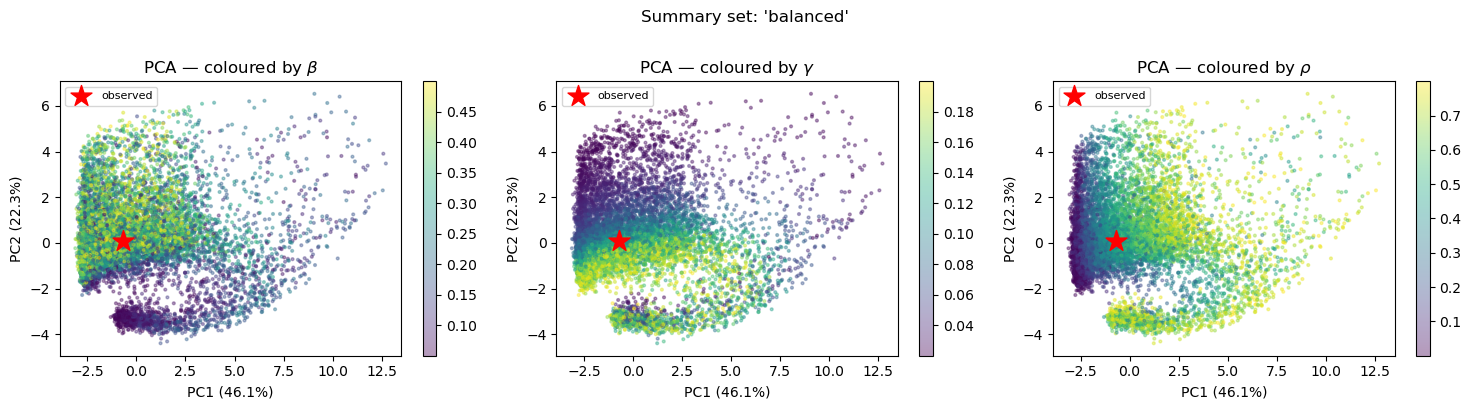

In [7]:
# ── PCA ───────────────────────────────────────────────────────────────────────
scaler = StandardScaler()
sim_scaled = scaler.fit_transform(sim_stats)
obs_scaled = scaler.transform(obs_stats[np.newaxis])

pca = PCA(n_components=2)
sim_pc = pca.fit_transform(sim_scaled)      # (M, 2)
obs_pc = pca.transform(obs_scaled)[0]       # (2,)

param_names = [r"$\beta$", r"$\gamma$", r"$\rho$"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, j, name in zip(axes, range(3), param_names):
    sc = ax.scatter(sim_pc[:, 0], sim_pc[:, 1],
                    c=thetas[:, j], cmap="viridis", s=4, alpha=0.4, rasterized=True)
    ax.scatter(*obs_pc, marker="*", s=250, c="red", zorder=5, label="observed")
    fig.colorbar(sc, ax=ax)
    ax.set(title=f"PCA — coloured by {name}",
           xlabel=f"PC1 ({pca.explained_variance_ratio_[0]:.1%})",
           ylabel=f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
    ax.legend(fontsize=8)
plt.suptitle(f"Summary set: '{ACTIVE_SET}'", y=1.01)
plt.tight_layout()

## 5. ABC-MCMC
We now swap in a local MCMC proposal mechanism and MH-style acceptance to generate correlated samples from the same ABC posterior.

In [28]:
# ── Config ────────────────────────────────────────────────────────────────────
QUANTILE = 0.01   # accept top 1 % closest draws

# ── Normalise & compute distances ─────────────────────────────────────────────
feat_std = sim_stats.std(axis=0).clip(min=1e-10)   # avoid div-by-zero
sim_norm = sim_stats / feat_std
obs_norm = obs_stats / feat_std_safe
print("distance check:", distance(fresh_stats))
data   = np.load(ROOT / "data" / "prior_simulations.npz")
thetas    = data["thetas"]             # (M, 3)
sim_inf   = data["infected_fractions"] # (M, R, T+1)
sim_rew   = data["rewire_counts"]      # (M, R, T+1)
sim_deg   = data["degree_histograms"]  # (M, R, 31)

sim_stats = compute_summaries(sim_inf, sim_rew, sim_deg)  # (M, n_features)

distances = np.linalg.norm(sim_norm - obs_norm, axis=1)   # (M,)

epsilon = np.quantile(distances, QUANTILE)
accepted = thetas[distances <= epsilon]
print(f"Tolerance ε = {epsilon:.4f}  |  Accepted {len(accepted):,} / {len(distances):,} "

      f"({len(accepted)/len(distances):.1%})")

distance check: 4048.127289986199
Tolerance ε = 1.2852  |  Accepted 100 / 10,000 (1.0%)


In [32]:
# ── Config ────────────────────────────────────────────────────────────────────
PRIOR_LOW   = np.array([0.05, 0.02, 0.0])
PRIOR_HIGH  = np.array([0.50, 0.20, 0.8])
N_STEPS     = 50_000
R           = 40
QUANTILE    = 0.01
PROPOSAL_SD = np.array([0.02, 0.005, 0.03])
SEED        = 42

rng = np.random.default_rng(SEED)

# ── Helpers ───────────────────────────────────────────────────────────────────
def in_prior(theta):
    return np.all(theta >= PRIOR_LOW) and np.all(theta <= PRIOR_HIGH)

def get_stats(theta, rng):
    results = [simulate_fast(*theta, rng=rng) for _ in range(R)]
    inf = np.array([r[0] for r in results])[np.newaxis]
    rew = np.array([r[1] for r in results])[np.newaxis]
    deg = np.array([r[2] for r in results])[np.newaxis]
    return compute_summaries(inf, rew, deg)[0]

def distance(s):
    return np.linalg.norm((s - obs_stats) / feat_std_safe)

# ── Calibrate ε ───────────────────────────────────────────────────────────────
feat_std_safe   = sim_stats.std(axis=0).clip(min=1e-10)
obs_norm        = obs_stats / feat_std_safe
sim_norm        = sim_stats / feat_std_safe
prior_distances = np.linalg.norm(sim_norm - obs_norm, axis=1)
epsilon         = np.quantile(prior_distances, QUANTILE)
print(f"ε = {epsilon:.4f}  (top {QUANTILE:.0%} of {len(prior_distances):,} prior draws)")

# ── Starting point ────────────────────────────────────────────────────────────
accepted_mask = prior_distances <= epsilon
current_theta = thetas[accepted_mask][0].copy()
current_dist  = prior_distances[accepted_mask][0]
print(f"Start: β={current_theta[0]:.3f}  γ={current_theta[1]:.3f}  ρ={current_theta[2]:.3f}  d={current_dist:.4f}")
print(f"       ({accepted_mask.sum()} prior draws inside ε)")

# ── MCMC chain ────────────────────────────────────────────────────────────────
chain    = np.empty((N_STEPS, 3))
accepted = 0

for step in range(N_STEPS):
    proposed_theta = current_theta + rng.normal(0, PROPOSAL_SD)

    if not in_prior(proposed_theta):
        chain[step] = current_theta
        continue

    proposed_dist = distance(get_stats(proposed_theta, rng))

    if proposed_dist < epsilon:
        current_theta = proposed_theta
        current_dist  = proposed_dist
        accepted += 1

    chain[step] = current_theta

    if step % 100 == 0:
        rate = accepted / max(step, 1)
        print(f"[{step:5d}/{N_STEPS}]  accept={rate:.1%}  current d={current_dist:.4f}  "
              f"β={current_theta[0]:.3f}  γ={current_theta[1]:.3f}  ρ={current_theta[2]:.3f}")

print(f"\nFinal acceptance rate: {accepted / N_STEPS:.1%}")

ε = 1.2852  (top 1% of 10,000 prior draws)
Start: β=0.211  γ=0.122  ρ=0.403  d=1.2775
       (100 prior draws inside ε)
[    0/50000]  accept=0.0%  current d=1.2775  β=0.211  γ=0.122  ρ=0.403
[  100/50000]  accept=7.0%  current d=1.0915  β=0.273  γ=0.110  ρ=0.323
[  200/50000]  accept=8.5%  current d=1.2269  β=0.345  γ=0.097  ρ=0.450
[  300/50000]  accept=11.7%  current d=0.8929  β=0.101  γ=0.073  ρ=0.247
[  400/50000]  accept=14.8%  current d=1.2584  β=0.142  γ=0.078  ρ=0.198
[  500/50000]  accept=17.4%  current d=1.1259  β=0.205  γ=0.102  ρ=0.364
[  600/50000]  accept=17.3%  current d=0.9233  β=0.227  γ=0.093  ρ=0.375
[  700/50000]  accept=17.4%  current d=1.2726  β=0.231  γ=0.094  ρ=0.300
[  800/50000]  accept=18.9%  current d=1.0190  β=0.142  γ=0.107  ρ=0.326
[  900/50000]  accept=18.9%  current d=1.1723  β=0.221  γ=0.127  ρ=0.361
[ 1000/50000]  accept=18.7%  current d=1.2078  β=0.314  γ=0.101  ρ=0.323
[ 1100/50000]  accept=17.2%  current d=0.8664  β=0.294  γ=0.107  ρ=0.361
[ 1200/

β:  mean=0.210  std=0.063  95% CI=[0.100, 0.331]
γ:  mean=0.095  std=0.021  95% CI=[0.061, 0.141]
ρ:  mean=0.336  std=0.064  95% CI=[0.209, 0.452]


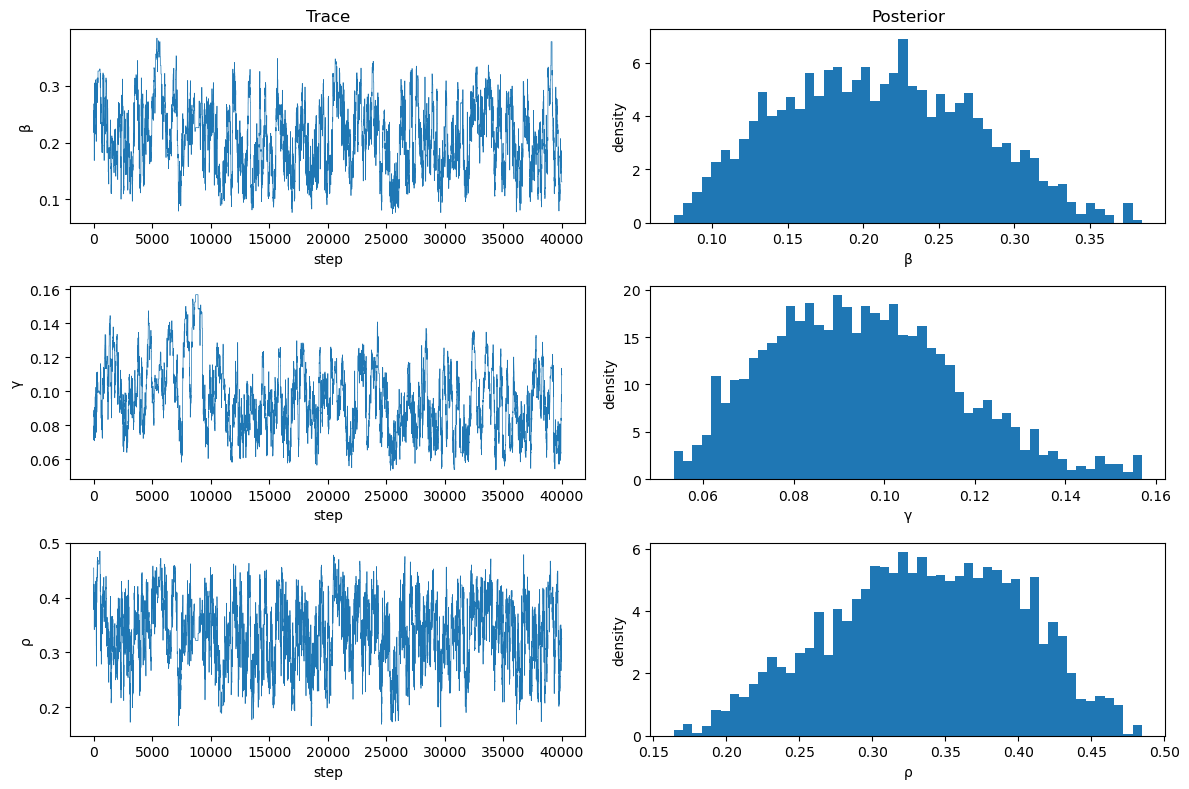

In [33]:
# ── Discard burn-in ───────────────────────────────────────────────────────────
burn_in    = 10000
chain_post = chain[burn_in:]

# ── Posterior summaries ───────────────────────────────────────────────────────
labels = ["β", "γ", "ρ"]
for i, name in enumerate(labels):
    samples = chain_post[:, i]
    print(f"{name}:  mean={samples.mean():.3f}  std={samples.std():.3f}  "
          f"95% CI=[{np.percentile(samples, 2.5):.3f}, {np.percentile(samples, 97.5):.3f}]")

# ── Trace plots + marginal posteriors ─────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 2, figsize=(12, 8))
for i, name in enumerate(labels):
    samples = chain_post[:, i]
    axes[i, 0].plot(samples, lw=0.5)
    axes[i, 0].set_ylabel(name)
    axes[i, 0].set_xlabel("step")
    axes[i, 1].hist(samples, bins=50, density=True)
    axes[i, 1].set_xlabel(name)
    axes[i, 1].set_ylabel("density")

axes[0, 0].set_title("Trace")
axes[0, 1].set_title("Posterior")
plt.tight_layout()
plt.show()